In [1]:
import io

import numpy as np
import neuromaps.datasets
import torch
from einops import rearrange
from matplotlib import pyplot as plt
from PIL import Image
import pyvista as pv
from scipy import ndimage

import yaspy
from yaspy._plotter import _crop_transparent_background, _border_mask

import flat_mae.transforms as flat_transforms
import flat_mae.nisc as nisc

In [2]:
plt.style.use("../clane.v2.mplstyle")
PLOTW = 3.25  # 6.75 two column width, 0.25 pad

In [3]:
resampler = nisc.flat_resampler_fslr64k_224_560()

parc_path = nisc.fetch_schaefer(400, space="fslr64k")
parc = nisc.read_cifti_surf_data(parc_path).squeeze(0).astype(np.int64)

roi_ids = np.arange(1, 401)
parc_one_hot = (roi_ids[:, None] == parc).astype(np.float32)
parc_one_hot = parc_one_hot / parc_one_hot.sum(axis=1, keepdims=True)

surfaces = neuromaps.datasets.fetch_fslr()
surf_lh_path, surf_rh_path = surfaces["inflated"]

In [4]:
grads = {}

# volume principal gradient
# (nb principal grad for volume is pc 2)
grad = np.load("results/pca_mni_cortex.npz")["components"][1]
grad = grad / grad.std()
unmask = flat_transforms.get_unmask("mni_cortex")
grad_ = np.zeros(unmask.mask.shape, dtype=grad.dtype)
grad_[unmask.mask.numpy()] = grad
grad = grad_
grads["mni_cortex"] = grad
print(f"volume: {grad.shape}")

# flat map
grad = np.load("results/pca_flat.npz")["components"][0]
grad = grad / grad.std()
grad_ = np.zeros(resampler.mask_.shape, dtype=grad.dtype)
grad_[resampler.mask_] = grad
grad = grad_
grads["flat"] = grad
print(f"flat: {grad.shape}")

# parcel
grad = np.load("results/pca_schaefer400.npz")["components"][0]
grad = -grad / grad.std()
grads["schaefer400"] = grad
print(f"schaefer400: {grad.shape}")

volume: (91, 109, 91)
flat: (224, 560)
schaefer400: (400,)


2026-04-02 10:22:27.980 (   7.785s) [    79D16949A740]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


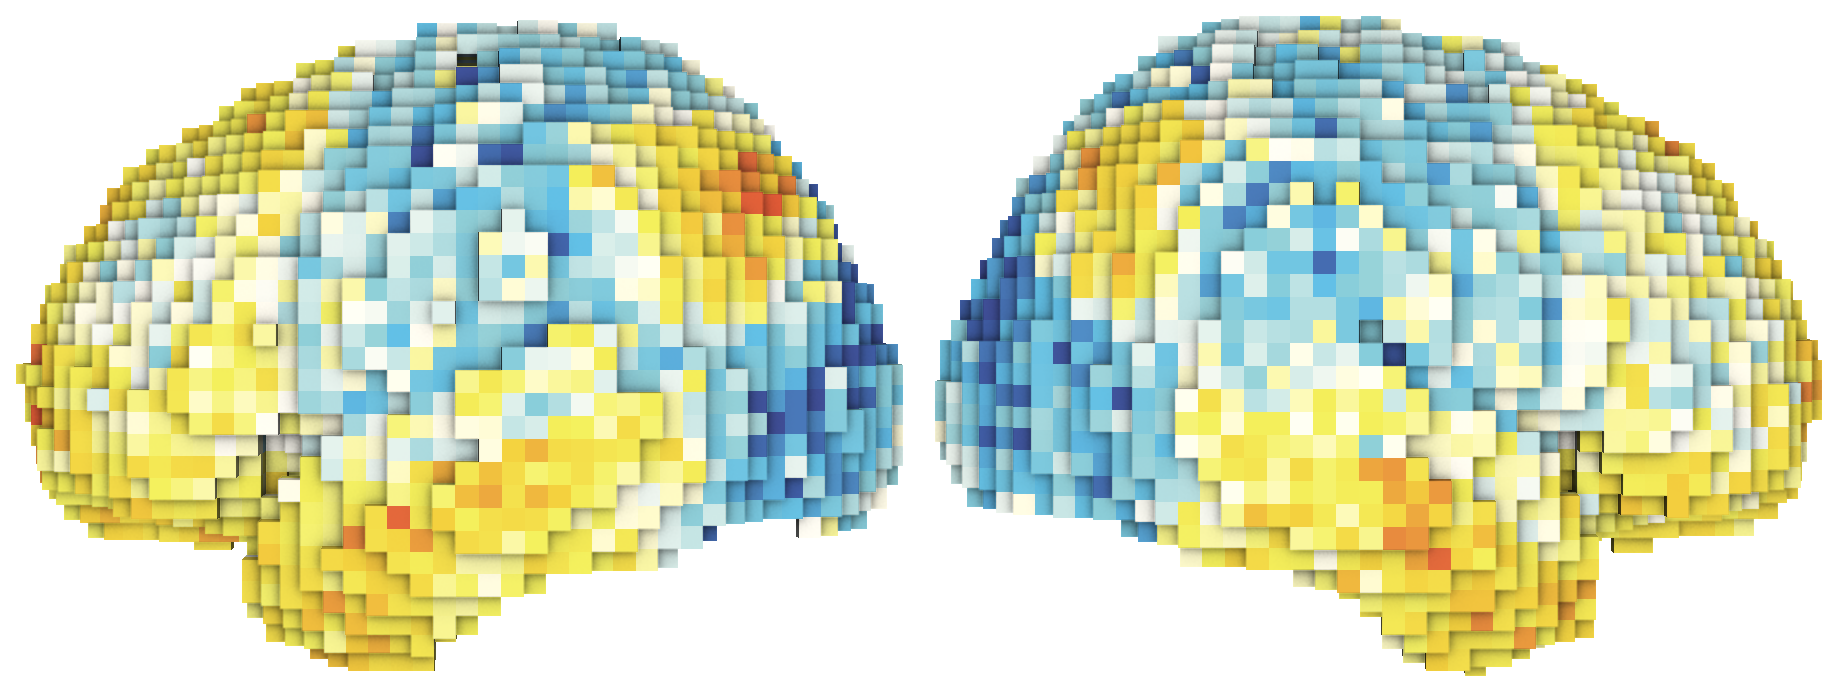

In [5]:
# volume space
cmap = nisc.FC_CMAP

vol = grads["mni_cortex"]  # shape: (Z, Y, X) = (91, 109, 91)
mask = vol != 0
mask = ndimage.binary_erosion(mask, iterations=1)
vol = mask * vol

# Downsample by 2x to make voxels more visible
DOWNSAMPLE = 2
vol = vol[::DOWNSAMPLE, ::DOWNSAMPLE, ::DOWNSAMPLE]
mask = mask[::DOWNSAMPLE, ::DOWNSAMPLE, ::DOWNSAMPLE]

grid = pv.ImageData(
    dimensions=(vol.shape[2] + 1, vol.shape[1] + 1, vol.shape[0] + 1),
    spacing=(DOWNSAMPLE, DOWNSAMPLE, DOWNSAMPLE),
)
grid.cell_data["bold"] = vol.T.flatten(order="F")

mask_vol = mask.astype(float)
grid.cell_data["mask"] = mask_vol.T.flatten(order="F")

# Threshold on mask to get brain voxels, but keep bold values for coloring
threshed = grid.threshold(value=0.5, scalars="mask")

# Create plotter
pl = pv.Plotter(off_screen=True, window_size=(1000, 1000))

pl.add_mesh(
    threshed,
    scalars="bold",
    cmap=cmap,
    clim=(-3, 3),
    show_scalar_bar=False,
)

for light in pl.renderer.lights:
    light.intensity *= 1.3

# Edge lines as a separate mesh for controllable width
EDGE_WIDTH = 1.0  # adjust this to control edge thickness
EDGE_COLOR = (0.2, 0.2, 0.2)
edges = threshed.extract_surface().extract_feature_edges(
    boundary_edges=False,
    non_manifold_edges=False,
    feature_angle=1,
)
# pl.add_mesh(edges, color=EDGE_COLOR, line_width=EDGE_WIDTH, render_lines_as_tubes=True, opacity=0.5)

# SSAO for depth perception
pl.enable_ssao(radius=5, bias=0.5, kernel_size=128)

# add boxes for select patches
PATCH_IDS = [
    # (7, 4, 2),
    # (7, 5, 1),
    # (7, 6, 1),
]
PATCH_SIZE = 8
for z, y, x in PATCH_IDS:
    s = PATCH_SIZE
    box = pv.Box(
        bounds=(
            x * s,
            (x + 1) * s,
            y * s,
            (y + 1) * s,
            z * s,
            (z + 1) * s,
        )
    )
    # pl.add_mesh(box, color="white", opacity=0.2, style="surface", show_edges=False)
    pl.add_mesh(
        box.extract_feature_edges(feature_angle=1),
        color="black",
        line_width=2,
        render_lines_as_tubes=True,
    )

# lateral view
center = (
    vol.shape[2] * DOWNSAMPLE / 2,
    vol.shape[1] * DOWNSAMPLE / 2,
    vol.shape[0] * DOWNSAMPLE / 2,
)
view_up = (0, 0, 1)

camera_pos = (-150, center[1], center[2])
pl.camera_position = [camera_pos, center, view_up]
img_l = pl.screenshot(return_img=True, transparent_background=True)
img_l = Image.fromarray(_crop_transparent_background(img_l))

camera_pos = (vol.shape[2] * DOWNSAMPLE + 150, center[1], center[2])
pl.camera_position = [camera_pos, center, view_up]
pl.render()
img_r = pl.screenshot(return_img=True, transparent_background=True)
img_r = Image.fromarray(_crop_transparent_background(img_r))

pl.close()
img = yaspy.montage([[img_l, img_r]], pad=16)
img.save("results/pca_mni_cortex.png")
img

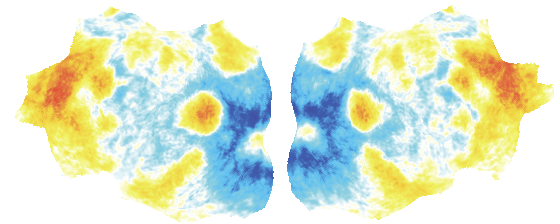

In [6]:
bold = grads["flat"]

mask = bold != 0
cmap = nisc.FC_CMAP
cmap.set_bad("none")
vmax = 3
bold = np.where(mask, bold, np.nan)
img = cmap(np.clip((bold + vmax) / (2 * vmax), 0, 1))
img = (255 * img).astype(np.uint8)
img = Image.fromarray(img)
# img = ImageEnhance.Brightness(img).enhance(1.0)
img.save("results/pca_flat.png")
img

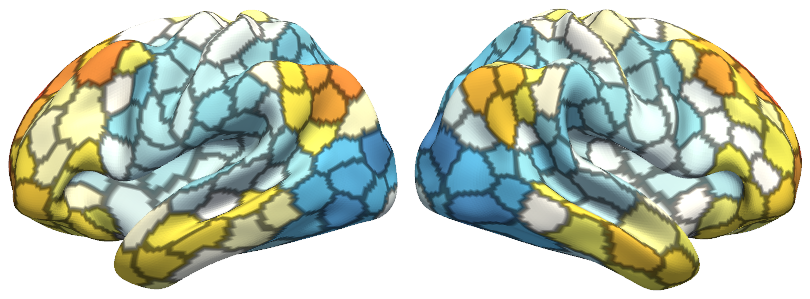

In [7]:
bold = grads["schaefer400"]

bold_ = np.zeros(parc.size, dtype=bold.dtype)
bold_[parc > 0] = bold[parc[parc > 0] - 1]
bold = bold_
bold_l, bold_r = np.split(bold, 2)
parc_l, parc_r = np.split(parc, 2)

plotter_l = yaspy.Plotter(surf_lh_path, hemi="lh", width=384)
plotter_l.overlay(
    np.where(bold_l != 0, bold_l, np.nan),
    cmap=nisc.FC_CMAP,
    vmin=-3,
    vmax=3,
)
plotter_l.border(parc_l, alpha=0.5)

for light in plotter_l._plotter.renderer.lights:
    light.intensity *= 1.3

img_l = plotter_l.screenshot()

plotter_r = yaspy.Plotter(surf_rh_path, hemi="rh", width=384)
plotter_r.overlay(
    np.where(bold_r != 0, bold_r, np.nan),
    cmap=nisc.FC_CMAP,
    vmin=-3,
    vmax=3,
)
plotter_r.border(parc_r, alpha=0.5)

for light in plotter_r._plotter.renderer.lights:
    light.intensity *= 1.3
img_r = plotter_r.screenshot()

img = yaspy.montage([[img_l, img_r]], pad=8)
img

In [8]:
parc_l, parc_r = np.split(parc, 2)

plotter_l = yaspy.Plotter(surf_lh_path, hemi="lh")
plotter_r = yaspy.Plotter(surf_rh_path, hemi="rh")
border_l = _border_mask(plotter_l._surf, parc_l)
border_r = _border_mask(plotter_r._surf, parc_r)
border_surf = np.concatenate([border_l, border_r])
border_flat = resampler.transform(border_surf)

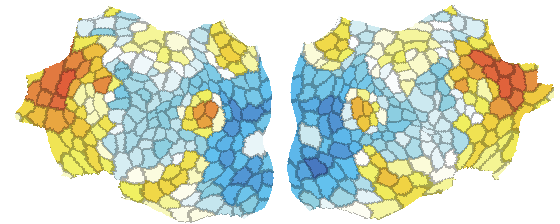

In [9]:
bold = grads["schaefer400"]

unmask = flat_transforms.get_unmask("schaefer400")
bold = unmask.to_flat(torch.from_numpy(bold[:, None])).numpy().squeeze()

mask = bold != 0
cmap = nisc.FC_CMAP
cmap.set_bad("none")
vmax = 3
bold = np.where(mask, bold, np.nan)
img = cmap(np.clip((bold + vmax) / (2 * vmax), 0, 1))
img = (255 * img).astype(np.uint8)
img = Image.fromarray(img)
# img = ImageEnhance.Brightness(img).enhance(0.8)

border_img = np.where(
    border_flat[:, :, None] > 0,
    np.array([0.0, 0.0, 0.0, 0.3]),
    np.array([1.0, 1.0, 1.0, 0.0]),
)
border_img = Image.fromarray((255 * border_img).astype(np.uint8))
img = Image.alpha_composite(img, border_img)

img

In [10]:
unmask = flat_transforms.get_unmask("schaefer400")
parc_flat = unmask.to_flat(torch.arange(1, 401)[:, None]).numpy().squeeze()

H, W = parc_flat.shape
points = np.stack(np.meshgrid(np.arange(W), np.arange(H)), axis=-1)

parc_xy = np.zeros((400, 2))
for ii in range(400):
    parc_xy[ii] = np.median(points[parc_flat == ii + 1], axis=0)

In [11]:
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

xmin, ymin = parc_xy.min(0)
xmax, ymax = parc_xy.max(0)
# h, w = 14, 34
h, w = 12, 36
grid = np.stack(np.meshgrid(np.linspace(xmin, xmax, w), np.linspace(ymin, ymax, h)), axis=-1)
grid = grid.reshape(-1, 2)

dist = cdist(parc_xy, grid)
rind, cind = linear_sum_assignment(dist)
parc_xy_grid = grid[cind]

grid_ij = np.stack(np.meshgrid(np.arange(w), np.arange(h)), axis=-1).reshape(-1, 2)
parc_ij_grid = grid_ij[cind]

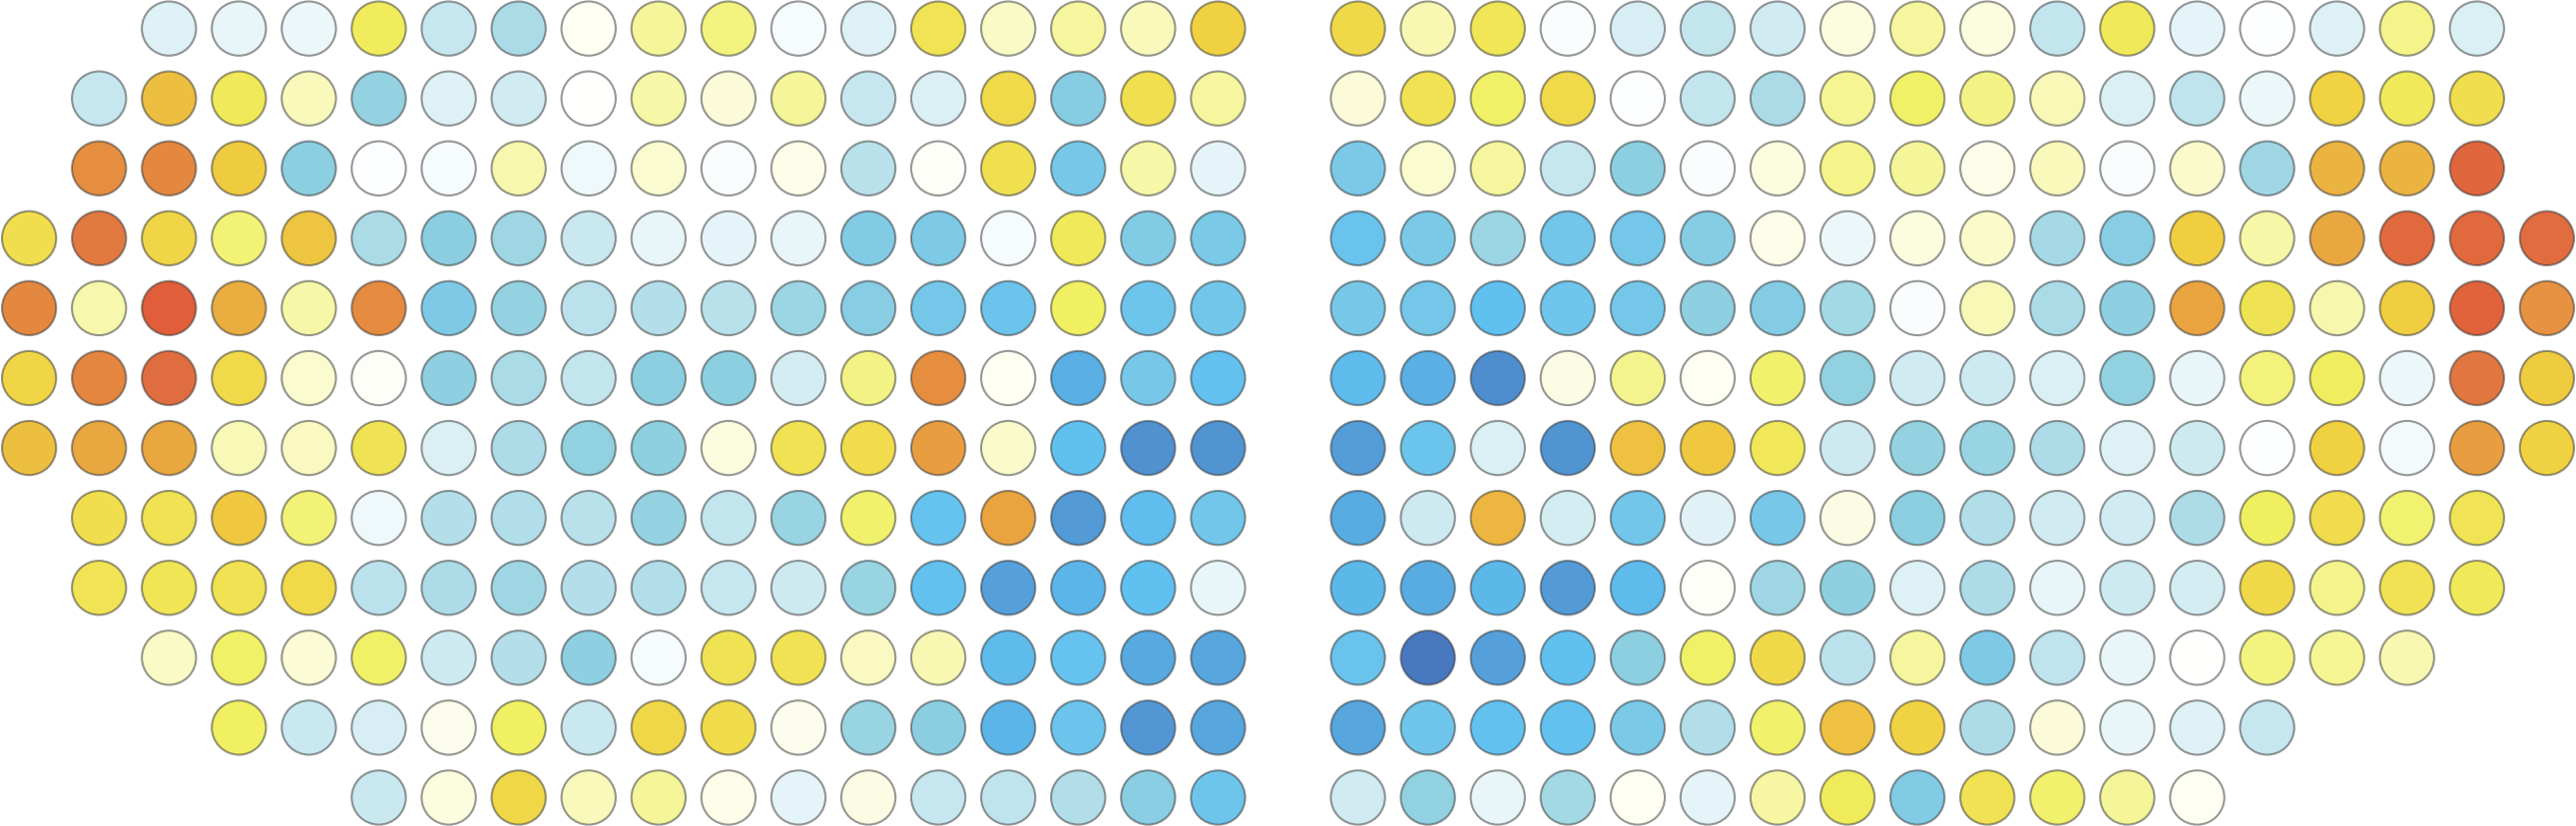

In [12]:
bold = grads["schaefer400"]

ploth = 3.0
plotw = ((w + 1) / h) * ploth
fig, ax = plt.subplots(figsize=(plotw, ploth))

offset = np.where(np.arange(400) < 200, 0, 1.0)
plt.scatter(
    offset + parc_ij_grid[:, 0],
    -parc_ij_grid[:, 1],
    s=170,
    c=bold,
    cmap=nisc.FC_CMAP,
    vmin=-3,
    vmax=3,
    ec=(0.2, 0.2, 0.2, 0.5),
    lw=0.5,
)
plt.axis("off")
ax = plt.gca()
ax.set_aspect("equal")
plt.subplots_adjust(0, 0, 1, 1)

with io.BytesIO() as f:
    fig.savefig(f, format="png", transparent=True)
    f.seek(0)
    img = Image.open(f)
    img.load()

plt.close(fig)

img = Image.fromarray(_crop_transparent_background(np.asarray(img)))
img.save("results/pca_schaefer400.png")
img

In [13]:
def plot_parcel_patches(
    bold: np.ndarray,
    nrow: int = 1,
    ncol: int = 6,
):
    """
    bold: array of parcel fmri values, shape (n_parcels,)

    plot a `nrow x ncol` grid of circle markers representing parcellated fmri values.
    rgb color values of each marker are color-mapped bold signal values. parcel indices
    selected by linear spaced indexing.
    """
    ec = "k"
    ms = 20
    cmap = nisc.FC_CMAP
    vmax = 3

    n_patches = nrow * ncol
    indices = np.linspace(0, len(bold) - 1, n_patches, dtype=int)
    patches = bold[indices]

    # Map values to RGBA colors
    normed = np.clip((patches + vmax) / (2 * vmax), 0, 1)
    colors = cmap(normed)

    fig, ax = plt.subplots(figsize=(ncol * 0.6, nrow * 0.6))

    for ii in range(n_patches):
        r = ii // ncol
        c = ii % ncol
        ax.plot(
            c,
            nrow - 1 - r,
            "o",
            color=colors[ii],
            markersize=ms,
            markeredgecolor=ec,
            markeredgewidth=1.0,
        )

    ax.set_xlim(-0.5, ncol - 0.5)
    ax.set_ylim(-0.5, nrow - 0.5)
    ax.set_aspect("equal")
    ax.axis("off")

    plt.tight_layout()
    return fig

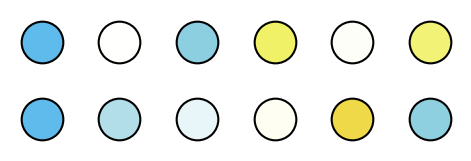

In [14]:
bold = grads["schaefer400"]
f = plot_parcel_patches(bold, 2, 6)
# f.savefig("results/patches_schaefer400.png", transparent=True, dpi=500)

In [15]:
def plot_flat_patches(
    bold: np.ndarray,
    nrow: int = 1,
    ncol: int = 6,
):
    """
    bold: array of parcel fmri values, shape (n_patches, patch_h, patch_w)

    plot a `nrow x ncol` grid of square patches representing the values of an fmri flat map.
    """
    ec = "k"
    cmap = nisc.FC_CMAP
    cmap.set_bad("gray")
    vmax = 3

    n_patches = nrow * ncol
    indices = np.linspace(0, len(bold) - 1, n_patches, dtype=int)
    patches = bold[indices]

    ph, pw = patches.shape[1], patches.shape[2]
    fig, axs = plt.subplots(nrow, ncol, figsize=(ncol * 0.6, nrow * 0.6))
    axs = axs.flatten()

    for ii, ax in enumerate(axs):
        patch = patches[ii]
        ax.imshow(
            np.where(patch != 0, patch, np.nan),
            cmap=cmap,
            vmin=-vmax,
            vmax=vmax,
            interpolation="none",
        )
        ax.set_aspect("equal")
        ax.axis("off")

        # Draw border around patch
        rect = plt.Rectangle(
            (-0.5, -0.5),
            pw,
            ph,
            linewidth=2.0,
            edgecolor=ec,
            facecolor="none",
        )
        ax.add_patch(rect)

    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    return fig

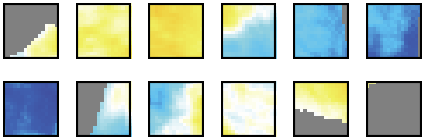

In [16]:
bold = grads["flat"]

H, W = bold.shape
bold = rearrange(bold, "(h p) (w q) -> (h w) p q", p=16, q=16)
mask = (bold != 0).any(axis=(1, 2))
bold = bold[mask]

f = plot_flat_patches(bold, 2, 6)
f.savefig("results/patches_flat.png", transparent=True, dpi=500)

In [17]:
def _render_volume_patch(patch, cmap, vmax, edge_color="k", bg_color="gray"):
    """Render a single 8x8x8 volume patch with PyVista, return RGBA screenshot."""
    d, h, w = patch.shape

    # Brain voxels mesh (colored by BOLD)
    grid = pv.ImageData(dimensions=(w + 1, h + 1, d + 1))
    grid.cell_data["values"] = patch.flatten(order="F")
    grid.cell_data["mask"] = (patch != 0).astype(np.float32).flatten(order="F")

    threshed = grid.threshold(value=0.5, scalars="mask", preference="cell")
    if threshed.n_cells == 0:
        return None

    # Color-map values to RGB
    normed = np.clip((threshed.cell_data["values"] + vmax) / (2 * vmax), 0, 1)
    colors = (cmap(normed)[:, :3] * 255).astype(np.uint8)
    threshed.cell_data["rgb"] = colors

    # Non-brain voxels mesh (gray fill)
    bg_threshed = grid.threshold(value=0.5, scalars="mask", preference="cell", invert=True)

    plotter = pv.Plotter(off_screen=True, window_size=(256, 256))

    # Add brain voxels without edges, flat lighting
    plotter.add_mesh(threshed, scalars="rgb", rgb=True, show_edges=False, lighting=False)

    # Add non-brain voxels as gray fill without edges, flat lighting
    if bg_threshed.n_cells > 0:
        plotter.add_mesh(bg_threshed, color=bg_color, show_edges=False, lighting=False)

    # Add wireframe outline of the full 8x8x8 bounding box
    outline = grid.outline()
    plotter.add_mesh(outline, color=edge_color, line_width=4.0)

    plotter.camera_position = "iso"
    plotter.camera.parallel_projection = True
    plotter.camera.zoom(1.0)
    img = plotter.screenshot(return_img=True, transparent_background=True)
    plotter.close()

    # Crop to non-transparent bounding box
    alpha = img[:, :, 3]
    rows = np.any(alpha > 0, axis=1)
    cols = np.any(alpha > 0, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    img = img[rmin : rmax + 1, cmin : cmax + 1]

    return img


def plot_volume_patches(
    bold: np.ndarray,
    nrow: int = 1,
    ncol: int = 6,
):
    """
    bold: array of parcel fmri values, shape (n_patches, patch_d, patch_h, patch_w)

    plot a `nrow x ncol` grid of cubes representing the values of an fmri cortical volume.
    """
    ec = "k"
    cmap = nisc.FC_CMAP
    cmap.set_bad("gray")
    vmax = 3

    n_patches = nrow * ncol
    indices = np.linspace(0, len(bold) - 1, n_patches, dtype=int)
    patches = bold[indices]

    # Render all patches
    screenshots = []
    for ii in range(n_patches):
        img = _render_volume_patch(patches[ii], cmap, vmax, edge_color=ec)
        screenshots.append(img)

    fig, axs = plt.subplots(nrow, ncol, figsize=(ncol * 0.6, nrow * 0.6))
    axs = np.atleast_2d(axs)

    for ii, ax in enumerate(axs.flat):
        if screenshots[ii] is not None:
            ax.imshow(screenshots[ii])
        ax.set_aspect("equal")
        ax.axis("off")

    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    return fig

(465, 8, 8, 8)


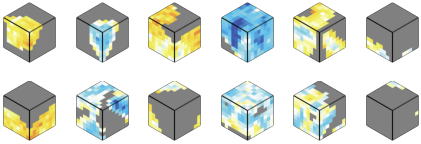

In [18]:
bold = grads["mni_cortex"]

unmask = flat_transforms.get_unmask("mni_cortex")
bold = bold[unmask.mask]
bold = unmask.transform(torch.from_numpy(bold)).numpy()
bold = bold.reshape(-1, 8, 8, 8)
print(bold.shape)

f = plot_volume_patches(bold, 2, 6)
f.savefig("results/patches_mni_cortex.png", transparent=True, dpi=500)